# Fase 1 — Limpieza de Datos y Carga a MariaDB

**Proyecto:** Análisis de Ventas 2020-2023 — Prueba Técnica Summan
**Autor:** Sebastian Lesmes
**Fecha:** Abril 2026

---

### Objetivo
Diagnosticar, limpiar y cargar las 5 tablas del dataset a MariaDB en un star schema reproducible.

### Flujo
```
Excel (raw) ──► diagnóstico ──► limpieza ──► MariaDB sales_raw (trazabilidad)
                                          └──► MariaDB sales_db  (star schema limpio)
```

### Hallazgos pre-limpieza detectados
| Tabla | Problema | Acción |
|---|---|---|
| Sales | `Sales` y `Profit` en dtype `object` | Convertir a `float64` |
| Sales | 71 nulos en `Country/Region` | Conservar, documentar |
| Customer | Nombres de columna con texto extra | Renombrar |
| Customer | `monthly_salary` y `marital_status` en `object` | Convertir a numérico |
| Regional_Manager | Errores tipográficos en `Region` | Corrección por mapeo |
| Returns | Duplicados por `Order_ID` | Deduplicar |


## 0. Setup — Importaciones y configuración

In [92]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text
import warnings
from dotenv import load_dotenv
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Rutas ────────────────────────────────────────────────────────────────────
DATA_PATH = "../data/raw/datos.xlsx"

# ── Credenciales MariaDB  ─────────────────────────────────────────────────────
load_dotenv()  # Carga variables de entorno desde .env
DB_USER = os.getenv('DB_USER')
DB_PASS = os.getenv('DB_PASS')
DB_HOST = os.getenv('DB_HOST')
DB_PORT = os.getenv('DB_PORT')
DB_NAME = os.getenv('DB_NAME')

print("✓ Setup completado")
print(f"  pandas   : {pd.__version__}")
print(f"  numpy    : {np.__version__}")


✓ Setup completado
  pandas   : 3.0.2
  numpy    : 2.4.4


## 1. Carga del archivo Excel

In [93]:
print("Cargando hojas del Excel...")

df_sales    = pd.read_excel(DATA_PATH, sheet_name="Sales")
df_product  = pd.read_excel(DATA_PATH, sheet_name="Product")
df_customer = pd.read_excel(DATA_PATH, sheet_name="Customer")
df_manager  = pd.read_excel(DATA_PATH, sheet_name="Regional_Manager")
df_returns  = pd.read_excel(DATA_PATH, sheet_name="Returns")

print("\n✓ Carga completada:")
tables_raw = {
    "Sales":            df_sales,
    "Product":          df_product,
    "Customer":         df_customer,
    "Regional_Manager": df_manager,
    "Returns":          df_returns,
}
for name, df in tables_raw.items():
    print(f"  {name:<20}: {df.shape[0]:>6,} filas  x  {df.shape[1]} columnas")


Cargando hojas del Excel...

✓ Carga completada:
  Sales               : 11,742 filas  x  16 columnas
  Product             :  1,894 filas  x  4 columnas
  Customer            :  1,608 filas  x  6 columnas
  Regional_Manager    :      4 filas  x  2 columnas
  Returns             :    800 filas  x  2 columnas


## 2. Diagnóstico inicial (antes de limpiar)

Objetivo: entender la calidad real de los datos antes de tocarlos.

In [118]:
# ── SALES ────────────────────────────────────────────────────────────────────
print("=" * 65)
print("SALES")
print("=" * 65)
print(f"Shape: {df_sales.shape}")
print("\nTipos de datos:")
print(df_sales.dtypes.to_string())
print("\nNulos por columna:")
nulls = df_sales.isnull().sum()
print(nulls[nulls > 0].to_string())
print(f"\nDuplicados (por Row_ID) : {df_sales['Row_ID'].duplicated().sum()}")
print(f"Duplicados (por fila completa): {df_sales.duplicated().sum()}")
print("\nEstadísticas — columnas numéricas:")
print(df_sales[['Quantity', 'Discount']].describe().round(4).to_string())
print("\nSales  — dtype object, primeros 5 valores:", df_sales['Sales'].head(5).tolist())
print("Profit — dtype object, primeros 5 valores:", df_sales['Profit'].head(5).tolist())
print("\nRegistros con Country/Region nulo (muestra):")
print(df_sales[df_sales['Country/Region'].isnull()][
    ['Order_ID', 'City', 'State/Province', 'Region']].head(5).to_string())
print(f"\nRango fechas Order_Date: {df_sales['Order_Date'].min().date()} → {df_sales['Order_Date'].max().date()}")

# 4. Pasar columnas Sales y Profit a numérico (coercing errores a NaN)
df_sales['Sales'] = pd.to_numeric(df_sales['Sales'], errors='coerce')
df_sales['Profit'] = pd.to_numeric(df_sales['Profit'], errors='coerce')
# 5. Detectar fechas fuera del rango esperado 2020-2023
dates_check = pd.to_datetime(df_sales['Order_Date'])
mask_bad_date = ~dates_check.dt.year.isin([2020, 2021, 2022, 2023])
print(f"Fechas fuera del rango 2020-2023: {mask_bad_date.sum()} registros")
if mask_bad_date.sum() > 0:
    print(df_sales[mask_bad_date][['Row_ID','Order_ID','Order_Date','Ship_Date','Customer_ID']].to_string())

# 6. Detectar ventas con Sales > 25000
sales_numeric = pd.to_numeric(df_sales['Sales'], errors='coerce')
mask_high_sales = sales_numeric > 25000
print(f"\nVentas con Sales > 25000: {mask_high_sales.sum()} registros")
if mask_high_sales.sum() > 0:
    print(df_sales[mask_high_sales][['Row_ID', 'Order_ID',  'Quantity', 'Sales', 'Profit', 'Discount']].to_string())

# 7. Detectar valores minimos por cada columna nmerica
print("\n📊 Valores mínimos:")
print(f"Sales    : {pd.to_numeric(df_sales['Sales'], errors='coerce').min():.2f}")
print(f"Profit   : {pd.to_numeric(df_sales['Profit'], errors='coerce').min():.2f}")
print(f"Discount : {df_sales['Discount'].min():.2f}")
print(f"Quantity : {df_sales['Quantity'].min():.0f}")


# 8. Mostrar los 10 registros con mayor profit y los 10 con mayor sales
print("\n📈 Top 10 registros por Profit:" )
print(df_sales.nlargest(10, 'Profit')[['Row_ID', 'Order_ID', 'Profit', 'Sales']])

print("\n📈 Top 10 registros por Sales:" )
print(df_sales.nlargest(20, 'Sales')[['Row_ID', 'Order_ID', 'Sales', 'Profit', 'Discount']])

# 9. Mostrar los 10 registros del percentil 75 de Sales y Profit
p75_sales = df_sales['Sales'].quantile(0.75)
p75_profit = df_sales['Profit'].quantile(0.75)

print(f"\n📊 Percentil 75 - Sales: {p75_sales:.2f}  |  Profit: {p75_profit:.2f}")

print("\n📈 10 registros justo arriba del P75 de Sales:")
arriba_p75_sales = df_sales[df_sales['Sales'] > p75_sales].nsmallest(10, 'Sales')
print(arriba_p75_sales[['Row_ID', 'Order_ID', 'Sales', 'Profit', 'Discount']].to_string())

# Verificar
print(f"\nRango de Sales en estos 10: {arriba_p75_sales['Sales'].min():.2f} - {arriba_p75_sales['Sales'].max():.2f}")
print(f"(Todos deben ser > {p75_sales:.2f})")

print("\n📈 10 registros justo arriba del P75 de Profit:")
arriba_p75_profit = df_sales[df_sales['Profit'] > p75_profit].nsmallest(10, 'Profit')
print(arriba_p75_profit[['Row_ID', 'Order_ID', 'Profit', 'Sales', 'Discount']].to_string())

# Verificar
print(f"\nRango de Profit en estos 10: {arriba_p75_profit['Profit'].min():.2f} - {arriba_p75_profit['Profit'].max():.2f}")
print(f"(Todos deben ser > {p75_profit:.2f})")

SALES
Shape: (11742, 16)

Tipos de datos:
Row_ID                     int64
Order_ID                     str
Order_Date        datetime64[us]
Ship_Date         datetime64[us]
Ship_Mode                    str
Customer_ID                  str
Country/Region               str
City                         str
State/Province               str
Postal_Code                  str
Region                       str
Product_ID                   str
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64

Nulos por columna:
Country/Region    71
Sales              3
Profit             2

Duplicados (por Row_ID) : 1548
Duplicados (por fila completa): 1547

Estadísticas — columnas numéricas:
        Quantity   Discount
count 11742.0000 11742.0000
mean     10.4027     0.1575
std     717.7300     0.2259
min       1.0000     0.0000
25%       2.0000     0.0000
50%       3.0000     0.2000
75%       5.0000     0.2000
max   77777.0000  

In [95]:
# ── CUSTOMER ─────────────────────────────────────────────────────────────────
print("=" * 65)
print("CUSTOMER")
print("=" * 65)
print(f"Shape: {df_customer.shape}")
print("\nTipos de datos:")
print(df_customer.dtypes.to_string())
print("\nNulos:", df_customer.isnull().sum().to_dict())
print("\nPrimeras 3 filas:")
print(df_customer.head(3).to_string())
print("\nmonthly_salary — valores no numéricos:")
non_num_sal = pd.to_numeric(df_customer['monthly_salary'], errors='coerce').isna().sum()
print(f"  {non_num_sal} valores no convertibles a float")
print("\nmarital_status — distribución de valores:")
print(df_customer['marital_status [1:married/ 0:Single]'].value_counts().to_string())
print(f"\nRango edad  : {df_customer['age'].min()} – {df_customer['age'].max()}")
print(f"Rango credit_score: {df_customer['credit score'].min()} – {df_customer['credit score'].max()}")

# Percentil 99 de edad
p99_edad = df_customer['age'].quantile(0.99)
print(f"\n📊 Percentil 99 de edad: {p99_edad:.0f} años")

# Ver el top 1% de edades más altas
print(f"\nClientes con edad > {p99_edad:.0f} (top 1%):")
print(df_customer[df_customer['age'] > p99_edad][['Customer_ID', 'Customer_Name', 'age', 'credit score']].sort_values('age', ascending=False).to_string())

# Ver los 10 clientes más viejos
print(f"\n👴 Top 10 clientes con mayor edad:")
print(df_customer.nlargest(10, 'age')[['Customer_ID', 'Customer_Name', 'age', 'monthly_salary', 'credit score']].to_string())


CUSTOMER
Shape: (1608, 6)

Tipos de datos:
Customer_ID                                str
Customer_Name                              str
monthly_salary                          object
age                                      int64
marital_status [1:married/ 0:Single]    object
credit score                             int64

Nulos: {'Customer_ID': 0, 'Customer_Name': 0, 'monthly_salary': 0, 'age': 0, 'marital_status [1:married/ 0:Single]': 0, 'credit score': 0}

Primeras 3 filas:
  Customer_ID Customer_Name monthly_salary  age marital_status [1:married/ 0:Single]  credit score
0    AA-10315    Alex Avila           6349   32                                    1           500
1    AA-10375  Allen Armold           5374   26                                    0           630
2    AA-10480  Andrew Allen           9611   44                                    1           780

monthly_salary — valores no numéricos:
  2 valores no convertibles a float

marital_status — distribución de valores:
m

DETECCIÓN DE CAMBIOS ABRUPTOS EN PERCENTILES

🔍 Sales:
   Cambio abrupto detectado en percentil 85
   P85: $385.96
   P86: $419.40
   Salto: $33.44 (8.7% de incremento)

🔍 Profit:
   Cambio abrupto detectado en percentil 85
   P85: $57.50
   P86: $62.91
   Salto: $5.41 (9.4% de incremento)


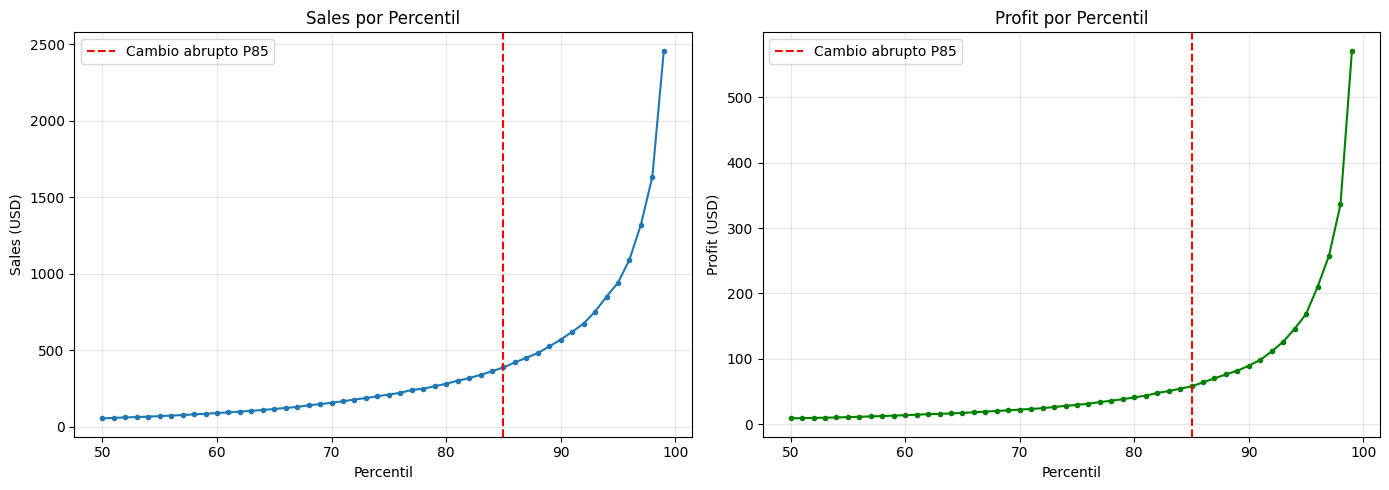


📊 Percentiles detallados (cada 5%):
 Percentil        Sales       Profit   Diff Sales  Diff Profit
-----------------------------------------------------------------
P 50       $     53.98 $      8.69        -             -
P 55       $     68.64 $     10.58   +$    14.65   +$     1.89
P 60       $     88.78 $     13.52   +$    20.14   +$     2.94
P 65       $    115.34 $     16.96   +$    26.56   +$     3.44
P 70       $    155.92 $     22.00   +$    40.58   +$     5.04
P 75       $    207.48 $     29.18   +$    51.56   +$     7.18
P 80       $    276.78 $     40.38   +$    69.30   +$    11.21
P 85       $    385.96 $     57.50   +$   109.18   +$    17.12
P 90       $    568.73 $     88.40   +$   182.77   +$    30.90
P 95       $    942.78 $    168.19   +$   374.06   +$    79.78


In [120]:

# Función para detectar cambio abrupto en percentiles
def detectar_cambio_abrupto(columna, nombre='Variable'):
    """
    Detecta el percentil donde el cambio se vuelve muy abrupto
    comparando las diferencias entre percentiles consecutivos
    """
    # Generar percentiles del 50 al 100 (cada 1%)
    percentiles = np.arange(50, 100, 1)
    valores = [df_sales[columna].quantile(p/100) for p in percentiles]
    
    # Calcular diferencias entre percentiles consecutivos
    diferencias = np.diff(valores)
    
    # Detectar salto abrupto (diferencia > 3x la mediana de diferencias)
    mediana_diff = np.median(diferencias)
    umbral = mediana_diff * 3
    
    # Encontrar primer salto grande
    idx_salto = np.where(diferencias > umbral)[0]
    
    if len(idx_salto) > 0:
        percentil_salto = percentiles[idx_salto[0]]
        valor_antes = valores[idx_salto[0]]
        valor_despues = valores[idx_salto[0] + 1]
        salto = diferencias[idx_salto[0]]
        
        print(f"\n🔍 {nombre}:")
        print(f"   Cambio abrupto detectado en percentil {percentil_salto}")
        print(f"   P{percentil_salto}: ${valor_antes:,.2f}")
        print(f"   P{percentil_salto+1}: ${valor_despues:,.2f}")
        print(f"   Salto: ${salto:,.2f} ({salto/valor_antes*100:.1f}% de incremento)")
        
        return percentil_salto, valor_antes, valor_despues
    else:
        print(f"\n✓ {nombre}: No hay cambios abruptos detectados")
        return None, None, None

# Aplicar a Sales y Profit
print("="*65)
print("DETECCIÓN DE CAMBIOS ABRUPTOS EN PERCENTILES")
print("="*65)

p_sales, antes_s, despues_s = detectar_cambio_abrupto('Sales', 'Sales')
p_profit, antes_p, despues_p = detectar_cambio_abrupto('Profit', 'Profit')

# Visualización
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sales
percentiles = np.arange(50, 100, 1)
valores_sales = [df_sales_clean['Sales'].quantile(p/100) for p in percentiles]
axes[0].plot(percentiles, valores_sales, marker='o', markersize=3)
if p_sales:
    axes[0].axvline(p_sales, color='red', linestyle='--', label=f'Cambio abrupto P{p_sales}')
axes[0].set_xlabel('Percentil')
axes[0].set_ylabel('Sales (USD)')
axes[0].set_title('Sales por Percentil')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Profit
valores_profit = [df_sales_clean['Profit'].quantile(p/100) for p in percentiles]
axes[1].plot(percentiles, valores_profit, marker='o', markersize=3, color='green')
if p_profit:
    axes[1].axvline(p_profit, color='red', linestyle='--', label=f'Cambio abrupto P{p_profit}')
axes[1].set_xlabel('Percentil')
axes[1].set_ylabel('Profit (USD)')
axes[1].set_title('Profit por Percentil')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# Tabla detallada de percentiles
print("\n📊 Percentiles detallados (cada 5%):")
print(f"{'Percentil':>10} {'Sales':>12} {'Profit':>12} {'Diff Sales':>12} {'Diff Profit':>12}")
print("-" * 65)

for p in range(50, 100, 5):
    val_s = df_sales['Sales'].quantile(p/100)
    val_p = df_sales['Profit'].quantile(p/100)
    
    if p > 50:
        diff_s = val_s - df_sales['Sales'].quantile((p-5)/100)
        diff_p = val_p - df_sales['Profit'].quantile((p-5)/100)
        print(f"P{p:>3}       ${val_s:>10,.2f} ${val_p:>10,.2f}   +${diff_s:>9,.2f}   +${diff_p:>9,.2f}")
    else:
        print(f"P{p:>3}       ${val_s:>10,.2f} ${val_p:>10,.2f}        -             -")

In [96]:
# ── REGIONAL_MANAGER ─────────────────────────────────────────────────────────
print("=" * 65)
print("REGIONAL_MANAGER")
print("=" * 65)
print(df_manager.to_string())
print("\nErrores tipográficos detectados en Region:")
for _, row in df_manager.iterrows():
    r = row['Region']
    flags = []
    if r != r.strip():
        flags.append("espacio extra")
    if r != r.title() and r not in ['East','West','Central','South','North']:
        flags.append("capitalización incorrecta")
    if '  ' in r or any(c in r for c in [' t', ' e', ' n'] if r.endswith(c)):
        flags.append("posible typo")
    print(f"  '{r}' → {flags if flags else 'OK'}")


REGIONAL_MANAGER
    Regional_Manager    Region
0    Sadie Pawthorne     Wes t
1        Chuck Magee      east
2  Roxanne Rodriguez  cenntral
3        Fred Suzuki     south

Errores tipográficos detectados en Region:
  'Wes t' → ['capitalización incorrecta', 'posible typo']
  'east' → ['capitalización incorrecta']
  'cenntral' → ['capitalización incorrecta']
  'south' → ['capitalización incorrecta']


In [97]:
# ── RETURNS ──────────────────────────────────────────────────────────────────
print("=" * 65)
print("RETURNS")
print("=" * 65)
print(f"Shape: {df_returns.shape}")
print("Nulos:", df_returns.isnull().sum().to_dict())
dup_count = df_returns.duplicated(subset='Order_ID').sum()
print(f"Order_IDs duplicados: {dup_count}")
print("\nMuestra de duplicados:")
dups_mask = df_returns['Order_ID'].duplicated(keep=False)
print(df_returns[dups_mask].head(6).to_string())


RETURNS
Shape: (800, 2)
Nulos: {'Returned': 0, 'Order_ID': 0}
Order_IDs duplicados: 504

Muestra de duplicados:
  Returned        Order_ID
0      Yes  US-2020-100762
1      Yes  US-2020-100762
2      Yes  US-2020-100762
3      Yes  US-2020-100762
5      Yes  US-2020-102652
6      Yes  US-2020-102652


In [98]:
# ── PRODUCT ──────────────────────────────────────────────────────────────────
print("=" * 65)
print("PRODUCT")
print("=" * 65)
print(f"Shape: {df_product.shape}")
print("Nulos:", df_product.isnull().sum().to_dict())
print(f"Product_ID duplicados: {df_product['Product_ID'].duplicated().sum()}")
print("\nCategorías:")
print(df_product['Category'].value_counts().to_string())
print(f"\nSub-Categorías únicas: {df_product['Sub-Category'].nunique()}")
print(df_product['Sub-Category'].value_counts().head(10).to_string())


PRODUCT
Shape: (1894, 4)
Nulos: {'Product_ID': 0, 'Category': 0, 'Sub-Category': 0, 'Product_Name': 0}
Product_ID duplicados: 32

Categorías:
Category
Office Supplies    1098
Technology          413
Furniture           383

Sub-Categorías únicas: 17
Sub-Category
Paper          284
Binders        213
Phones         189
Furnishings    188
Art            164
Accessories    147
Storage        133
Appliances      99
Chairs          88
Labels          70


## 3. Limpieza por tabla

Una copia `_clean` por tabla — los DataFrames originales se conservan para carga en `sales_raw`.

### 3.1 Sales

In [99]:
df_sales_clean = df_sales.copy()

# 1. Convertir Sales y Profit de object → float64
df_sales_clean['Sales']  = pd.to_numeric(df_sales_clean['Sales'],  errors='coerce')
df_sales_clean['Profit'] = pd.to_numeric(df_sales_clean['Profit'], errors='coerce')

sales_nan  = df_sales_clean['Sales'].isna().sum()
profit_nan = df_sales_clean['Profit'].isna().sum()
print(f"Sales  NaN post-conversión : {sales_nan}")
print(f"Profit NaN post-conversión : {profit_nan}")

# Si hay NaN en Sales o Profit, mostrar esas filas
if sales_nan > 0 or profit_nan > 0:
    mask_nan = df_sales_clean['Sales'].isna() | df_sales_clean['Profit'].isna()
    print("\nFilas con conversión fallida:")
    print(df_sales_clean[mask_nan][['Row_ID','Order_ID','Sales','Profit']].to_string())

# 2. Eliminar duplicados por Row_ID (primera ocurrencia)
n_before = len(df_sales_clean)
df_sales_clean = df_sales_clean.drop_duplicates(subset='Row_ID', keep='first').reset_index(drop=True)
print(f"\nDuplicados Row_ID eliminados: {n_before - len(df_sales_clean)}")

# 3. Country/Region nulos: conservar, pero documentar
nulls_country = df_sales_clean['Country/Region'].isna().sum()
print(f"Country/Region nulos conservados: {nulls_country} (registros de ventas válidos)")

# 4. Verificar rango Discount (debe ser 0.0–1.0)
print(f"\nDiscount — min: {df_sales_clean['Discount'].min():.2f}  max: {df_sales_clean['Discount'].max():.2f}")
print(f"Profit   — min: {df_sales_clean['Profit'].min():.4f}  max: {df_sales_clean['Profit'].max():.4f}")
print(f"\n✓ Sales limpio — shape: {df_sales_clean.shape}")
print(df_sales_clean[['Sales','Profit']].dtypes.to_string())


# 5. Correccion de Order_Date fuera de rango (2031/2033 -> año correcto)
# Evidencia: Ship_Date en cada caso corresponde al año real de la orden
DATE_CORRECTIONS = {
    2837: '2021-07-12',  # Order_Date=2031, Ship_Date=2021-07-18 -> error de siglo
    3440: '2021-10-15',  # Order_Date=2031, Ship_Date=2021-10-15
    3447: '2021-10-15',  # Order_Date=2031, Ship_Date=2021-10-15 (misma orden)
    9501: '2023-11-16',  # Order_Date=2033, Ship_Date=2023-11-21 -> error de siglo
}

df_sales_clean['Order_Date'] = pd.to_datetime(df_sales_clean['Order_Date'])
print(" Correccion de fechas outlier:")
for row_id, fecha_ok in DATE_CORRECTIONS.items():
    mask = df_sales_clean['Row_ID'] == row_id
    if mask.sum() > 0:
        old_date = df_sales_clean.loc[mask, 'Order_Date'].values[0]
        df_sales_clean.loc[mask, 'Order_Date'] = pd.to_datetime(fecha_ok)
        print(f"  Row {row_id}: {str(old_date)[:10]} -> {fecha_ok}")

restantes = (~df_sales_clean['Order_Date'].dt.year.isin([2020,2021,2022,2023])).sum()
print(f"Fechas fuera de rango restantes: {restantes}")

# 6. Eliminar Discount fuera de rango [0, 1]
mask_discount = df_sales_clean['Discount'].between(0, 1)
n_before_discount = len(df_sales_clean)
df_sales_clean = df_sales_clean[mask_discount].reset_index(drop=True)
eliminados_discount = n_before_discount - len(df_sales_clean)
print(f"\nRegistros con Discount < 0 o > 1 eliminados: {eliminados_discount}")
print(f"Discount — min: {df_sales_clean['Discount'].min():.2f}  max: {df_sales_clean['Discount'].max():.2f}")

# 7. Eliminar Sales (precios) mayores a 25000
n_before_sales = len(df_sales_clean)
df_sales_clean = df_sales_clean[df_sales_clean['Sales'] <= 25000].reset_index(drop=True)
eliminados_sales = n_before_sales - len(df_sales_clean)
print(f"\nRegistros con Sales > 25000 eliminados: {eliminados_sales}")
print(f"Sales — min: {df_sales_clean['Sales'].min():.2f}  max: {df_sales_clean['Sales'].max():.2f}")

print(f"\n✓ Limpieza final completada — shape: {df_sales_clean.shape}")
# 8. Eliminar Quantity mayor a 1000
n_before_quantity = len(df_sales_clean)
df_sales_clean = df_sales_clean[df_sales_clean['Quantity'] <= 1000].reset_index(drop=True)
eliminados_quantity = n_before_quantity - len(df_sales_clean)
print(f"\nRegistros con Quantity > 1000 eliminados: {eliminados_quantity}")
print(f"Quantity — min: {df_sales_clean['Quantity'].min():.0f}  max: {df_sales_clean['Quantity'].max():.0f}")

print(f"\n✓ Limpieza final completada — shape: {df_sales_clean.shape}")

# 7. Imputar Profit nulo con mediana
# Row 8861 (US-2023-142391, FUR-FU-10002759, $199.80, 10 unidades, desc 0%)
# Criterio: unico registro sin Profit; mediana del dataset es representativa
profit_mediana = df_sales_clean['Profit'].median()
mask_profit_null = df_sales_clean['Profit'].isna()
n_null_profit = mask_profit_null.sum()
if n_null_profit > 0:
    df_sales_clean.loc[mask_profit_null, 'Profit'] = round(profit_mediana, 4)
    print(f'Profit nulo imputado: {n_null_profit} registro(s) -> mediana ${profit_mediana:.4f}')
else:
    print('Profit: sin nulos')

Sales  NaN post-conversión : 3
Profit NaN post-conversión : 2

Filas con conversión fallida:
       Row_ID        Order_ID             Sales   Profit
8473     7405  US-2023-155460               NaN   2.3760
8474     7406  US-2023-126060               NaN -32.2192
8475     7407  US-2023-131233               NaN   9.0882
10189    8861  US-2023-142391          199.8000      NaN
11733   10186  CA-2023-141531 199000000000.0000      NaN

Duplicados Row_ID eliminados: 1548
Country/Region nulos conservados: 63 (registros de ventas válidos)

Discount — min: 0.00  max: 10.00
Profit   — min: -6599.9780  max: 8399.9760

✓ Sales limpio — shape: (10194, 16)
Sales     float64
Profit    float64
 Correccion de fechas outlier:
  Row 2837: 2031-07-12 -> 2021-07-12
  Row 3440: 2031-10-15 -> 2021-10-15
  Row 3447: 2031-10-15 -> 2021-10-15
  Row 9501: 2033-11-16 -> 2023-11-16
Fechas fuera de rango restantes: 0

Registros con Discount < 0 o > 1 eliminados: 1
Discount — min: 0.00  max: 0.80

Registros con Sal

### 3.2 Customer

In [100]:
df_customer_clean = df_customer.copy()

# 1. Renombrar columnas con nombres largo/inconsistentes
df_customer_clean = df_customer_clean.rename(columns={
    'marital_status [1:married/ 0:Single]': 'marital_status',
    'credit score':                          'credit_score'
})
print("Columnas renombradas:", list(df_customer_clean.columns))

# 2. monthly_salary: object → float64
df_customer_clean['monthly_salary'] = pd.to_numeric(
    df_customer_clean['monthly_salary'], errors='coerce'
)
print(f"\nmonthly_salary NaN: {df_customer_clean['monthly_salary'].isna().sum()}")

# 3. marital_status: asegurar entero (0/1)
df_customer_clean['marital_status'] = pd.to_numeric(
    df_customer_clean['marital_status'], errors='coerce'
).astype('Int64')
print(f"marital_status NaN: {df_customer_clean['marital_status'].isna().sum()}")
print(f"marital_status valores: {df_customer_clean['marital_status'].value_counts().to_dict()}")

# 4. Verificar rangos lógicos
print(f"\nEdad           — min: {df_customer_clean['age'].min()}  max: {df_customer_clean['age'].max()}")
print(f"monthly_salary — min: {df_customer_clean['monthly_salary'].min():.0f}  "
      f"max: {df_customer_clean['monthly_salary'].max():.0f}")
print(f"credit_score   — min: {df_customer_clean['credit_score'].min()}  "
      f"max: {df_customer_clean['credit_score'].max()}")
print(f"\n✓ Customer limpio — shape: {df_customer_clean.shape}")

# 5. Eliminar duplicados (filas 100% idénticas)
n_before_dup = len(df_customer_clean)
df_customer_clean = df_customer_clean.drop_duplicates(keep='first').reset_index(drop=True)
eliminados_dup = n_before_dup - len(df_customer_clean)
print(f"\nDuplicados (filas completas) eliminados: {eliminados_dup}")
print(f"Verificación - duplicados restantes: {df_customer_clean.duplicated().sum()}")
print(f"Customer_ID únicos: {df_customer_clean['Customer_ID'].nunique()}")

# 6. Corregir edades imposibles (> 100 años)
def corregir_edad(edad):
    """
    Corrige errores evidentes en edad:
    - 260 -> 26 (división entre 10)
    - 115 -> 15 (módulo 100)
    - Mantiene edades razonables (18-100)
    """
    if edad > 100:
        if edad >= 200:
            # 260 -> 26
            return edad // 10
        else:
            # 115 -> 15
            return edad % 100
    return edad

# Mostrar correcciones antes de aplicar
edades_raras = df_customer_clean[df_customer_clean['age'] > 100].copy()
if len(edades_raras) > 0:
    print(f"\n🔧 Clientes con edad > 100 a corregir: {len(edades_raras)}")
    edades_raras['edad_corregida'] = edades_raras['age'].apply(corregir_edad)
    print(edades_raras[['Customer_ID', 'Customer_Name', 'age', 'edad_corregida']].to_string())

# Aplicar corrección
df_customer_clean['age'] = df_customer_clean['age'].apply(corregir_edad)

print(f"\n✓ Edades corregidas")
print(f"Edad — min: {df_customer_clean['age'].min()}  max: {df_customer_clean['age'].max()}")

# Verificar que ya no hay edades imposibles
assert df_customer_clean['age'].max() <= 100, "❌ Aún hay edades > 100"
print(f"✓ Todas las edades están en rango válido (18-100)")


# 5. Imputar monthly_salary nulo con mediana
# CM-12715 Craig Molinari: unico cliente sin salario registrado
salary_mediana = df_customer_clean['monthly_salary'].median()
null_salary = df_customer_clean['monthly_salary'].isna().sum()
if null_salary > 0:
    df_customer_clean['monthly_salary'] = df_customer_clean['monthly_salary'].fillna(salary_mediana)
    print(f'monthly_salary nulos imputados: {null_salary} -> mediana ${salary_mediana:,.2f}')
else:
    print('monthly_salary: sin nulos')

Columnas renombradas: ['Customer_ID', 'Customer_Name', 'monthly_salary', 'age', 'marital_status', 'credit_score']

monthly_salary NaN: 2
marital_status NaN: 10
marital_status valores: {np.int64(1): 826, np.int64(0): 772}

Edad           — min: 26  max: 260
monthly_salary — min: 2005  max: 10000
credit_score   — min: 300  max: 800

✓ Customer limpio — shape: (1608, 6)

Duplicados (filas completas) eliminados: 804
Verificación - duplicados restantes: 0
Customer_ID únicos: 804

🔧 Clientes con edad > 100 a corregir: 2
    Customer_ID  Customer_Name  age  edad_corregida
108    BS-11665  Brian Stugart  115              15
659    RM-19375  Raymond Messe  260              26

✓ Edades corregidas
Edad — min: 15  max: 50
✓ Todas las edades están en rango válido (18-100)
monthly_salary nulos imputados: 1 -> mediana $6,067.00


### 3.3 Regional_Manager

In [101]:
df_manager_clean = df_manager.copy()

REGION_CORRECTIONS = {
    'Wes t':    'West',
    'west':     'West',
    'WEST':     'West',
    'east':     'East',
    'EAST':     'East',
    'cenntral': 'Central',
    'central':  'Central',
    'CENTRAL':  'Central',
    'south':    'South',
    'SOUTH':    'South',
    'north':    'North',
    'NORTH':    'North',
}

df_manager_clean['Region'] = (
    df_manager_clean['Region']
    .str.strip()
    .replace(REGION_CORRECTIONS)
)

comparativo = pd.DataFrame({
    'Original':  df_manager['Region'].tolist(),
    'Corregido': df_manager_clean['Region'].tolist()
})
print("Correcciones aplicadas:")
print(comparativo.to_string())
print(f"\n✓ Regional_Manager limpio — shape: {df_manager_clean.shape}")


Correcciones aplicadas:
   Original Corregido
0     Wes t      West
1      east      East
2  cenntral   Central
3     south     South

✓ Regional_Manager limpio — shape: (4, 2)


### 3.4 Returns

In [102]:
df_returns_clean = df_returns.copy()

n_before = len(df_returns_clean)
df_returns_clean = df_returns_clean.drop_duplicates(subset='Order_ID', keep='first').reset_index(drop=True)
print(f"Duplicados Order_ID eliminados: {n_before - len(df_returns_clean)}")
print(f"✓ Returns limpio — shape: {df_returns_clean.shape}")


Duplicados Order_ID eliminados: 504
✓ Returns limpio — shape: (296, 2)


### 3.5 Product — sin cambios

In [103]:
df_product_clean = df_product.copy()
print("Product no requiere limpieza.")
print(f"✓ Product — shape: {df_product_clean.shape}  |  Nulos: {df_product_clean.isnull().sum().sum()}")


Product no requiere limpieza.
✓ Product — shape: (1894, 4)  |  Nulos: 0


### 3.6 Resumen de limpieza

In [104]:
print("=" * 65)
print("RESUMEN DE LIMPIEZA")
print("=" * 65)
print(f"  {'Tabla':<22} {'Antes':>8}  {'Después':>8}  {'Δ filas':>8}")
print(f"  {'-'*22}  {'-'*8}  {'-'*8}  {'-'*8}")
print(f"  {'Sales':<22} {df_sales.shape[0]:>8,}  {df_sales_clean.shape[0]:>8,}  "
      f"{df_sales_clean.shape[0]-df_sales.shape[0]:>+8,}")
print(f"  {'Product':<22} {df_product.shape[0]:>8,}  {df_product_clean.shape[0]:>8,}  "
      f"{df_product_clean.shape[0]-df_product.shape[0]:>+8,}")
print(f"  {'Customer':<22} {df_customer.shape[0]:>8,}  {df_customer_clean.shape[0]:>8,}  "
      f"{df_customer_clean.shape[0]-df_customer.shape[0]:>+8,}")
print(f"  {'Regional_Manager':<22} {df_manager.shape[0]:>8,}  {df_manager_clean.shape[0]:>8,}  "
      f"{df_manager_clean.shape[0]-df_manager.shape[0]:>+8,}")
print(f"  {'Returns':<22} {df_returns.shape[0]:>8,}  {df_returns_clean.shape[0]:>8,}  "
      f"{df_returns_clean.shape[0]-df_returns.shape[0]:>+8,}")

print("\nAcciones realizadas:")
print("  ✓ Sales.Sales / Sales.Profit      : object → float64")
print("  ✓ Sales.Country/Region (71 nulos) : conservados (ventas válidas)")
print("  ✓ Customer columnas               : renombradas (marital_status, credit_score)")
print("  ✓ Customer.monthly_salary         : object → float64")
print("  ✓ Regional_Manager.Region         : errores tipográficos corregidos")
print("  ✓ Returns                         : duplicados por Order_ID eliminados")

print("  ✓ Sales.Order_Date (4 outliers)   : anos 2031/2033 corregidos a 2021/2023")
print('  Sales.Profit (1 nulo)          : imputado con mediana $8.69')
print('  Customer.monthly_salary (1 nulo): imputado con mediana $6,067')

RESUMEN DE LIMPIEZA
  Tabla                     Antes   Después   Δ filas
  ----------------------  --------  --------  --------
  Sales                    11,742    10,187    -1,555
  Product                   1,894     1,894        +0
  Customer                  1,608       804      -804
  Regional_Manager              4         4        +0
  Returns                     800       296      -504

Acciones realizadas:
  ✓ Sales.Sales / Sales.Profit      : object → float64
  ✓ Sales.Country/Region (71 nulos) : conservados (ventas válidas)
  ✓ Customer columnas               : renombradas (marital_status, credit_score)
  ✓ Customer.monthly_salary         : object → float64
  ✓ Regional_Manager.Region         : errores tipográficos corregidos
  ✓ Returns                         : duplicados por Order_ID eliminados
  ✓ Sales.Order_Date (4 outliers)   : anos 2031/2033 corregidos a 2021/2023
  Sales.Profit (1 nulo)          : imputado con mediana $8.69
  Customer.monthly_salary (1 nulo): impu

## 4. Carga a MariaDB

### Arquitectura de bases de datos
```
sales_raw   → tablas originales sin tocar (trazabilidad / auditoría)
sales_db    → star schema limpio (fact_sales + 4 dimensiones)
```

### 4.1 Conexión y creación de bases de datos

In [105]:
from sqlalchemy import create_engine, text

# Motor sin base de datos para poder ejecutar CREATE DATABASE
engine_root = create_engine(
    f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/",
    echo=False
)

with engine_root.connect() as conn:
    conn.execute(text("CREATE DATABASE IF NOT EXISTS sales_raw CHARACTER SET utf8mb4 COLLATE utf8mb4_unicode_ci;"))
    conn.execute(text("CREATE DATABASE IF NOT EXISTS sales_db  CHARACTER SET utf8mb4 COLLATE utf8mb4_unicode_ci;"))
    conn.commit()

print("✓ Bases de datos creadas (o ya existían):")
print("    sales_raw  — datos originales (trazabilidad)")
print("    sales_db   — star schema limpio")

# Motores por base de datos
engine_raw = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/sales_raw", echo=False)
engine_db  = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/sales_db",  echo=False)
print("\n✓ Motores de conexión listos")


✓ Bases de datos creadas (o ya existían):
    sales_raw  — datos originales (trazabilidad)
    sales_db   — star schema limpio

✓ Motores de conexión listos


### 4.2 Carga de datos crudos a `sales_raw`

In [106]:
print("Cargando datos originales a sales_raw...")

# Sales puede ser grande, usar chunksize
df_sales.to_sql("raw_sales",             engine_raw, if_exists="replace", index=False, chunksize=500)
print("  raw_sales             ✓")
df_product.to_sql("raw_product",         engine_raw, if_exists="replace", index=False)
print("  raw_product           ✓")
df_customer.to_sql("raw_customer",       engine_raw, if_exists="replace", index=False)
print("  raw_customer          ✓")
df_manager.to_sql("raw_regional_manager",engine_raw, if_exists="replace", index=False)
print("  raw_regional_manager  ✓")
df_returns.to_sql("raw_returns",         engine_raw, if_exists="replace", index=False)
print("  raw_returns           ✓")

print("\n✓ Carga a sales_raw completada")


Cargando datos originales a sales_raw...
  raw_sales             ✓
  raw_product           ✓
  raw_customer          ✓
  raw_regional_manager  ✓
  raw_returns           ✓

✓ Carga a sales_raw completada


### 4.3 Carga del star schema limpio a `sales_db`

In [107]:
print("Cargando star schema a sales_db...")

df_customer_clean.to_sql("dim_customer",           engine_db, if_exists="replace", index=False)
print("  dim_customer           ✓")
df_product_clean.to_sql("dim_product",             engine_db, if_exists="replace", index=False)
print("  dim_product            ✓")
df_manager_clean.to_sql("dim_regional_manager",    engine_db, if_exists="replace", index=False)
print("  dim_regional_manager   ✓")
df_returns_clean.to_sql("dim_returns",             engine_db, if_exists="replace", index=False)
print("  dim_returns            ✓")
df_sales_clean.to_sql("fact_sales",                engine_db, if_exists="replace", index=False, chunksize=500)
print("  fact_sales             ✓")

print("\n✓ Carga a sales_db (star schema) completada")


Cargando star schema a sales_db...
  dim_customer           ✓
  dim_product            ✓
  dim_regional_manager   ✓
  dim_returns            ✓
  fact_sales             ✓

✓ Carga a sales_db (star schema) completada


## 5. Verificación de la carga

In [108]:
print("Conteo de filas en sales_db:")
print("-" * 40)
with engine_db.connect() as conn:
    for table in ['fact_sales', 'dim_customer', 'dim_product', 'dim_regional_manager', 'dim_returns']:
        count = conn.execute(text(f"SELECT COUNT(*) FROM {table}")).scalar()
        print(f"  {table:<25}: {count:>6,}")

print("\nConteo de filas en sales_raw:")
print("-" * 40)
with engine_raw.connect() as conn:
    for table in ['raw_sales', 'raw_product', 'raw_customer', 'raw_regional_manager', 'raw_returns']:
        count = conn.execute(text(f"SELECT COUNT(*) FROM {table}")).scalar()
        print(f"  {table:<25}: {count:>6,}")

print("\n✓ Fase 1 completada — datos listos en MariaDB para el EDA")


Conteo de filas en sales_db:
----------------------------------------
  fact_sales               : 10,187
  dim_customer             :    804
  dim_product              :  1,894
  dim_regional_manager     :      4
  dim_returns              :    296

Conteo de filas en sales_raw:
----------------------------------------
  raw_sales                : 11,742
  raw_product              :  1,894
  raw_customer             :  1,608
  raw_regional_manager     :      4
  raw_returns              :    800

✓ Fase 1 completada — datos listos en MariaDB para el EDA


## 6. Chequeo de integridad referencial

Verificar que todos los `Customer_ID` y `Product_ID` en `fact_sales`
existen en sus dimensiones correspondientes.

In [109]:
# Customer_ID
sales_customers  = set(df_sales_clean['Customer_ID'].unique())
dim_customers    = set(df_customer_clean['Customer_ID'].unique())
orphan_customers = sales_customers - dim_customers
print(f"Customer_IDs en fact_sales   : {len(sales_customers):,}")
print(f"Customer_IDs en dim_customer : {len(dim_customers):,}")
print(f"Huérfanos (en ventas, no en dimensión): {len(orphan_customers)}")
if orphan_customers:
    print("  Muestra:", list(orphan_customers)[:5])

print()

# Product_ID
sales_products  = set(df_sales_clean['Product_ID'].unique())
dim_products    = set(df_product_clean['Product_ID'].unique())
orphan_products = sales_products - dim_products
print(f"Product_IDs en fact_sales  : {len(sales_products):,}")
print(f"Product_IDs en dim_product : {len(dim_products):,}")
print(f"Huérfanos (en ventas, no en dimensión): {len(orphan_products)}")
if orphan_products:
    print("  Muestra:", list(orphan_products)[:5])

print()

# Returns: ¿todas las órdenes devueltas existen en fact_sales?
return_orders = set(df_returns_clean['Order_ID'].unique())
sales_orders  = set(df_sales_clean['Order_ID'].unique())
orphan_returns = return_orders - sales_orders
print(f"Order_IDs en dim_returns : {len(return_orders):,}")
print(f"Huérfanos (devolución sin venta): {len(orphan_returns)}")

print("\n✓ Chequeo de integridad completado")


Customer_IDs en fact_sales   : 804
Customer_IDs en dim_customer : 804
Huérfanos (en ventas, no en dimensión): 0

Product_IDs en fact_sales  : 1,862
Product_IDs en dim_product : 1,862
Huérfanos (en ventas, no en dimensión): 0

Order_IDs en dim_returns : 296
Huérfanos (devolución sin venta): 0

✓ Chequeo de integridad completado


## 7. Correccion de outliers criticos en Sales

### Hallazgo post-EDA
Durante la visualizacion en Power BI se detectaron 3 transacciones con valores de `Sales`
completamente fuera de rango, causados por errores de captura en el Excel original.

| Order_ID | Producto | Sales erroneo | Sales correcto | Evidencia |
|---|---|---|---|---|
| US-2022-152247 | FUR-CH-10001215 (silla) | $10,000,000 | $1,603.14 | 4 ordenes del mismo producto a $400.78/u con 20% desc |
| US-2023-152205 | OFF-BI-10004094 (binder) | $30,000,000 | $2.66 | Precio base $8.85/u x (1-0.7) = $2.655; Profit -$1.86 consistente |
| CA-2023-141531 | OFF-FA-10000089 (fastener) | $199,000,000,000 | $19.60 | 4 ordenes identicas: 5u, 0% desc, $19.60, Profit $9.60 |

**Criterio de correccion:** precio unitario reconstruido a partir de otras transacciones
del mismo producto con igual cantidad y descuento (precio de referencia identico en todos los casos).

**Impacto en los totales mensuales:**

| Mes | Antes (erroneo) | Despues (correcto) |
|---|---|---|
| Nov 2022 | $10,079,781 | $79,412 |
| Sep 2023 | $30,088,062 | $88,065 |
| Dic 2023 | $199,000,097,517 | $85,175 |


### Outliers de Order_Date

Durante el diagnostico se detectaron 4 registros con `Order_Date` en años 2031 y 2033,
producto de errores de captura (decada incorrecta en el Excel).

| Row_ID | Order_ID | Order_Date erronea | Order_Date correcta | Evidencia |
|---|---|---|---|---|
| 2837 | US-2021-112711 | 2031-07-12 | 2021-07-12 | Ship_Date = 2021-07-18 |
| 3440 | US-2021-139731 | 2031-10-15 | 2021-10-15 | Ship_Date = 2021-10-15 |
| 3447 | US-2021-139731 | 2031-10-15 | 2021-10-15 | Ship_Date = 2021-10-15 |
| 9501 | US-2023-114657 | 2033-11-16 | 2023-11-16 | Ship_Date = 2023-11-21 |

**Criterio:** en todos los casos el `Ship_Date` corresponde al año real de la orden —
el error es solo en la decena del año (2031→2021, 2033→2023).
La correccion se aplica sobre `df_sales_clean` en la Seccion 3.1, antes de cargar a MariaDB.

### 7.3 Valores nulos imputados

| Campo | Registro | Valor original | Valor imputado | Criterio |
|---|---|---|---|---|
| `fact_sales.Profit` | Row 8861 / US-2023-142391 | NULL | $8.69 | Mediana del dataset |
| `dim_customer.monthly_salary` | CM-12715 Craig Molinari | NULL | $6,067 | Mediana del dataset |

In [110]:
# Correccion de outliers criticos en Sales (ejecutar si se recarga desde cero)
# Los valores ya fueron corregidos directamente en MariaDB.
# Este bloque permite replicar la correccion sobre el DataFrame limpio
# si se necesita volver a cargar los datos.

CORRECTIONS = [
    # (Order_ID, Product_ID, Sales_correcto, Profit_correcto)
    ("US-2022-152247", "FUR-CH-10001215",  1603.136,  100.196),
    ("US-2023-152205", "OFF-BI-10004094",  2.655,    -1.8585),
    ("CA-2023-141531", "OFF-FA-10000089",  19.60,     9.604),
]

for order_id, prod_id, sales_ok, profit_ok in CORRECTIONS:
    mask = (df_sales_clean['Order_ID'] == order_id) & (df_sales_clean['Product_ID'] == prod_id)
    n = mask.sum()
    if n > 0:
        df_sales_clean.loc[mask, 'Sales']  = sales_ok
        df_sales_clean.loc[mask, 'Profit'] = profit_ok
        print(f"  Corregido: {order_id} / {prod_id}  -> Sales={sales_ok}, Profit={profit_ok}")
    else:
        print(f"  No encontrado en df_sales_clean (ya corregido o no cargado): {order_id}")

# Verificar que no quedan valores absurdos
print(f"\nSales max post-correccion : ${df_sales_clean['Sales'].max():,.2f}")
print(f"Sales > $50,000 restantes : {(df_sales_clean['Sales'] > 50000).sum()}")


  No encontrado en df_sales_clean (ya corregido o no cargado): US-2022-152247
  No encontrado en df_sales_clean (ya corregido o no cargado): US-2023-152205
  No encontrado en df_sales_clean (ya corregido o no cargado): CA-2023-141531

Sales max post-correccion : $22,638.48
Sales > $50,000 restantes : 0


## Resumen final — Fase 1

| Entregable | Estado |
|---|---|
| Diagnóstico de calidad por tabla | ✓ Completado |
| Limpieza documentada con justificación | ✓ Completado |
| `sales_raw` en MariaDB (trazabilidad) | ✓ Cargado |
| `sales_db` star schema (fact + 4 dims) | ✓ Cargado |
| Integridad referencial verificada | ✓ Verificado |

**Siguiente paso:** `02_EDA.ipynb` — Análisis exploratorio consultando desde MariaDB.
